## Importing rdkit

In [21]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from IPython.display import SVG, display

## Molecule dataset

The five selected molecules are:

1. Aspirin
2. Caffeine
3. Serotonin
4. Dopamine
5. GABA

In [16]:
molecules = {
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Serotonin": "C1=CC2=C(C=C1O)C(=CN2)CCN",
    "Dopamine": "C1=CC(=C(C=C1CCN)O)O",
    "GABA": "C(CC(=O)O)CN",
}

## Convert SMILES into RDKit molecule objects

`Chem.MolFromSmiles()` reads a SMILES string and converts it into an RDKit molecule object.

In [17]:
mol_objects = {}

for name, smiles in molecules.items():
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print(f"{name}: invalid SMILES")
    else:
        mol_objects[name] = mol
        print(f"{name}: molecule created successfully")

Aspirin: molecule created successfully
Caffeine: molecule created successfully
Serotonin: molecule created successfully
Dopamine: molecule created successfully
GABA: molecule created successfully


## Generate canonical SMILES

Canonical SMILES provide a standardized SMILES representation for each molecule.

In [18]:
for name, mol in mol_objects.items():
    canonical_smiles = Chem.MolToSmiles(mol)

    print(f"{name}")
    print(f"Canonical SMILES: {canonical_smiles}")
    print()

Aspirin
Canonical SMILES: CC(=O)Oc1ccccc1C(=O)O

Caffeine
Canonical SMILES: Cn1c(=O)c2c(ncn2C)n(C)c1=O

Serotonin
Canonical SMILES: NCCc1c[nH]c2ccc(O)cc12

Dopamine
Canonical SMILES: NCCc1ccc(O)c(O)c1

GABA
Canonical SMILES: NCCCC(=O)O



## Compute molecular descriptors

For each molecule, I will calculate:

- Draw Each Molecule
- Molecular weight using `Descriptors.MolWt()`
- LogP using `Descriptors.MolLogP()`

Aspirin


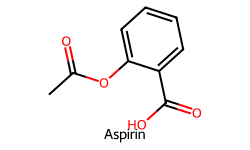

Molecular weight: 180.16 g/mol
LogP: 1.31
----------------------------------------
Caffeine


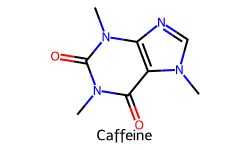

Molecular weight: 194.19 g/mol
LogP: -1.03
----------------------------------------
Serotonin


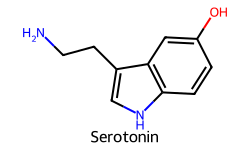

Molecular weight: 176.22 g/mol
LogP: 1.37
----------------------------------------
Dopamine


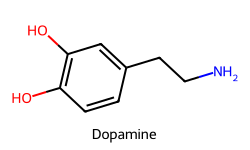

Molecular weight: 153.18 g/mol
LogP: 0.60
----------------------------------------
GABA


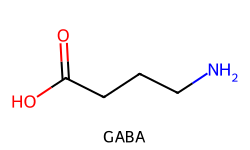

Molecular weight: 103.12 g/mol
LogP: -0.19
----------------------------------------


In [30]:
for name, mol in mol_objects.items():
    molecular_weight = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)

    print(f"{name}")

    svg = Draw.MolsToGridImage(
        [mol],
        molsPerRow=1,
        subImgSize=(250, 150),
        legends=[name],
        useSVG=True
    )

    display(svg)

    print(f"Molecular weight: {molecular_weight:.2f} g/mol")
    print(f"LogP: {logp:.2f}")
    print("-" * 40)